In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import os


In [2]:
os.getcwd()

'/mnt/c/Users/c68440/OneDrive - Textron/Documents/Berkeley/DS_207/Final proj'

In [3]:
# for fine annotations
fine_lookup_df = pd.read_csv(
    "./Anno_fine/list_attr_cloth.txt",
    sep=r"\s+",      # split on ANY amount of whitespace
    skiprows=1,      # skip the first line (289222)
    header=0         # use the second line as header
)
#fine_lookup_df['key'] = fine_lookup_df.index+1
fine_lookup_df
#my_headers = ['image_name', 'attribute_labels']+list(fine_lookup_df['attribute_name'].unique())
my_headers = list(fine_lookup_df['attribute_name'].unique())
print(my_headers)

# key is attribute type number, value is string, use a lambda function to assign this to a new column in the fine_label_df
attribute_to_string_dict = {1: 'pattern', 2: 'sleeve style', 3: 'dress type', 4: 'neckline', 5: 'material', 6:'fit'}
fine_lookup_df['attribute_type_str'] = fine_lookup_df['attribute_type'].apply(lambda x: attribute_to_string_dict[x])
fine_lookup_df.set_index('attribute_name', inplace=True)# for easy lookup later

fine_label_df = pd.read_csv(
    "./Anno_fine/train_attr.txt",
    sep=r"\s+",      # split on ANY amount of whitespace
    #skiprows=1,      # skip the first line (289222)
    names=my_headers        # use the second line as header
)

fine_train_image_name_df = pd.read_csv(
    "./Anno_fine/train.txt",
    sep=r"\s+",      # split on ANY amount of whitespace
    #skiprows=1,      # skip the first line (289222)
    names = ['img_name']      # use the second line as header
)
fine_category_train_df = pd.read_csv(
    "./Anno_fine/train_cate.txt",
    sep=r"\s+",      # split on ANY amount of whitespace
    #skiprows=1,      # skip the first line (289222)
    names = ['category']      # use the second line as header
)

fine_category_lookup_df = pd.read_csv('./Anno_fine/list_category_cloth.txt',
                                       sep=r"\s+", skiprows=1, header=0)
fine_category_lookup_df['key'] = fine_category_lookup_df.index+1

train_df = pd.concat([fine_train_image_name_df, fine_label_df], axis=1)

train_df_with_category = pd.concat([fine_train_image_name_df, fine_category_train_df], axis=1)
train_df_with_category = train_df_with_category.merge(fine_category_lookup_df, left_on='category', right_on='key', how='left')

fine_category_lookup_df.set_index('category_name', inplace=True)# for lookup later
category_dict = {1: 'upper body', 2: 'lower body', 3: 'full body'}
fine_category_lookup_df['category_type_str'] = fine_category_lookup_df['category_type'].apply(lambda x: category_dict[x])




['floral', 'graphic', 'striped', 'embroidered', 'pleated', 'solid', 'lattice', 'long_sleeve', 'short_sleeve', 'sleeveless', 'maxi_length', 'mini_length', 'no_dress', 'crew_neckline', 'v_neckline', 'square_neckline', 'no_neckline', 'denim', 'chiffon', 'cotton', 'leather', 'faux', 'knit', 'tight', 'loose', 'conventional']


In [4]:


fine_category_lookup_df

,category_type,key,category_type_str
category_name,,,
Anorak,1,1,upper body
Blazer,1,2,upper body
Blouse,1,3,upper body
Bomber,1,4,upper body
Button-Down,1,5,upper body
Cardigan,1,6,upper body
Flannel,1,7,upper body
Halter,1,8,upper body
Henley,1,9,upper body


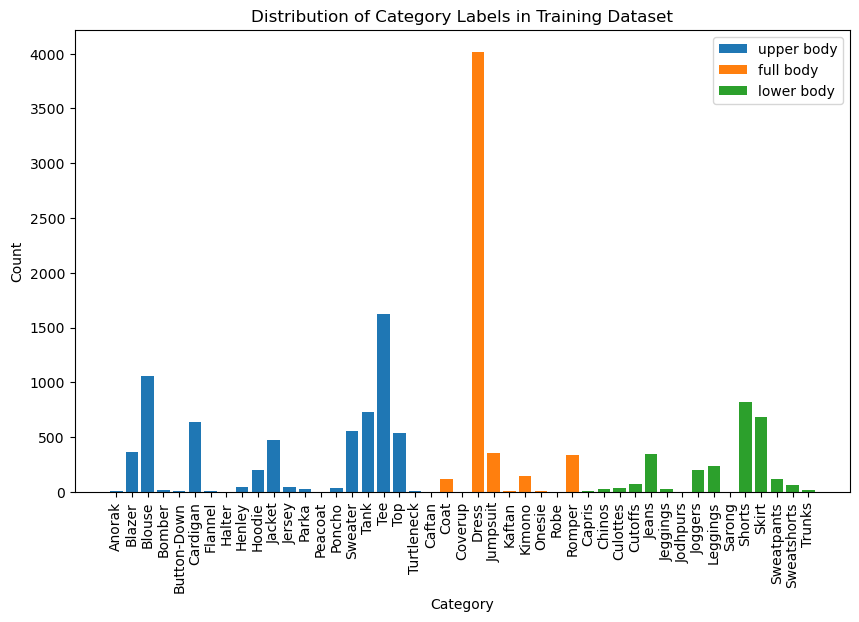

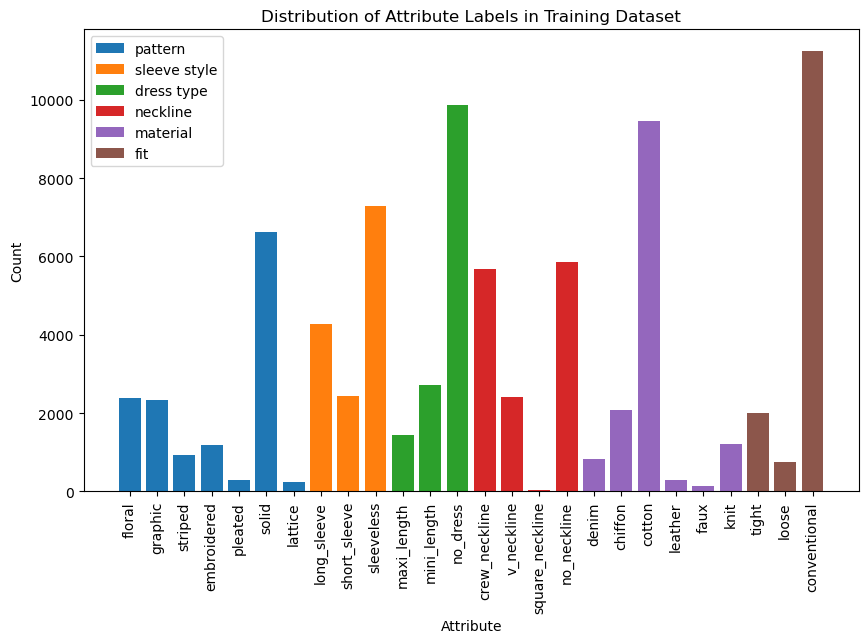

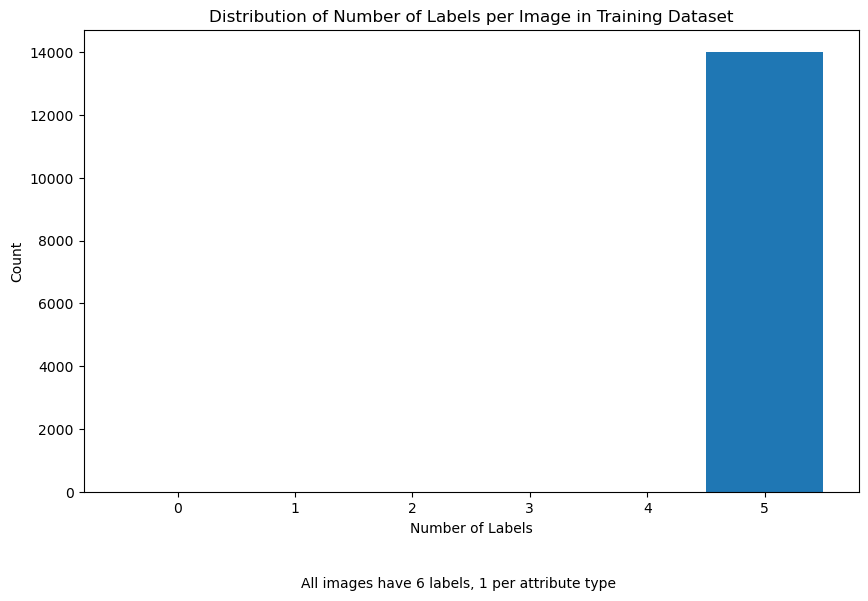

In [5]:
# get dist of all categories
cat_count_df =pd.DataFrame(train_df_with_category.groupby('category_name').size(), columns=['count'])
cat_count_df['category_type'] = cat_count_df.apply(lambda x:fine_category_lookup_df.loc[x.name, 'category_type_str'], axis=1)
plt.figure(figsize=(10,6))
for category_type in cat_count_df['category_type'].unique():
    subset = cat_count_df[cat_count_df['category_type'] == category_type]
    plt.bar(subset.index, subset['count'], label=category_type)
plt.xticks(rotation=90)
plt.title('Distribution of Category Labels in Training Dataset')
plt.xlabel('Category')
plt.ylabel('Count')
plt.legend()
plt.show()

# get dist of all labels
attr_count_df = pd.DataFrame(fine_label_df.sum(), columns=['count'])
attr_count_df['attribute_type'] = attr_count_df.apply(lambda x:fine_lookup_df.loc[x.name, 'attribute_type_str'], axis=1)
plt.figure(figsize=(10,6))
for attribute_type in attr_count_df['attribute_type'].unique():
    subset = attr_count_df[attr_count_df['attribute_type'] == attribute_type]
    plt.bar(subset.index, subset['count'], label=attribute_type)
plt.xticks(rotation=90)
plt.title('Distribution of Attribute Labels in Training Dataset')
plt.xlabel('Attribute')
plt.ylabel('Count')
plt.legend()
plt.show()

# get dist of num labels per image
train_df['num_labels'] = train_df.drop(columns=['img_name']).sum(axis=1)
plt.figure(figsize=(10,6))
plt.hist(train_df['num_labels'], bins=range(0, train_df['num_labels'].max()+1), align='left')
plt.title('Distribution of Number of Labels per Image in Training Dataset')
plt.xlabel('Number of Labels')
plt.ylabel('Count')
plt.figtext(0.5, -0.05, 'All images have 6 labels, 1 per attribute type', ha='center')
plt.show()



In [4]:
cat_master_df = pd.read_csv(
    "./Anno_coarse/list_category_cloth.txt",
    sep=r"\s+",      # split on ANY amount of whitespace
    skiprows=1,      # skip the first line (289222)
    header=0         # use the second line as header
)
cat_master_df['key'] = cat_master_df.index+1
cat_master_df

,category_name,category_type,key
0,Anorak,1,1
1,Blazer,1,2
2,Blouse,1,3
3,Bomber,1,4
4,Button-Down,1,5
5,Cardigan,1,6
6,Flannel,1,7
7,Halter,1,8
8,Henley,1,9
9,Hoodie,1,10


In [5]:


label_df = pd.read_csv(
    "./Anno_coarse/list_category_img.txt",
    sep=r"\s+",      # split on ANY amount of whitespace
    skiprows=1,      # skip the first line (289222)
    header=0         # use the second line as header
)

label_df

,image_name,category_label
0,img/Sheer_Pleated-Front_Blouse/img_00000001.jpg,3
1,img/Sheer_Pleated-Front_Blouse/img_00000002.jpg,3
2,img/Sheer_Pleated-Front_Blouse/img_00000003.jpg,3
3,img/Sheer_Pleated-Front_Blouse/img_00000004.jpg,3
4,img/Sheer_Pleated-Front_Blouse/img_00000005.jpg,3
...,...,...
289217,img/Paisley_Print_Babydoll_Dress/img_00000050.jpg,41
289218,img/Paisley_Print_Babydoll_Dress/img_00000051.jpg,41
289219,img/Paisley_Print_Babydoll_Dress/img_00000052.jpg,41
289220,img/Paisley_Print_Babydoll_Dress/img_00000053.jpg,41


In [6]:
df_merged = label_df.merge(cat_master_df, left_on="category_label", right_on ='key' , how="left")
df_merged


,image_name,category_label,category_name,category_type,key
0,img/Sheer_Pleated-Front_Blouse/img_00000001.jpg,3,Blouse,1,3
1,img/Sheer_Pleated-Front_Blouse/img_00000002.jpg,3,Blouse,1,3
2,img/Sheer_Pleated-Front_Blouse/img_00000003.jpg,3,Blouse,1,3
3,img/Sheer_Pleated-Front_Blouse/img_00000004.jpg,3,Blouse,1,3
4,img/Sheer_Pleated-Front_Blouse/img_00000005.jpg,3,Blouse,1,3
...,...,...,...,...,...
289217,img/Paisley_Print_Babydoll_Dress/img_00000050.jpg,41,Dress,3,41
289218,img/Paisley_Print_Babydoll_Dress/img_00000051.jpg,41,Dress,3,41
289219,img/Paisley_Print_Babydoll_Dress/img_00000052.jpg,41,Dress,3,41
289220,img/Paisley_Print_Babydoll_Dress/img_00000053.jpg,41,Dress,3,41


In [7]:
# check for nas - None
df_merged.isna().sum()

image_name        0
category_label    0
category_name     0
category_type     0
key               0
dtype: int64

In [10]:
df_merged.groupby('category_name').size().sort_values()

category_name
Coverup           17
Halter            17
Sarong            32
Jodhpurs          45
Gauchos           49
Caftan            54
Onesie            70
Capris            77
Peacoat           97
Kaftan           126
Turtleneck       146
Robe             150
Anorak           160
Bomber           309
Flannel          324
Button-Down      330
Trunks           386
Culottes         486
Chinos           527
Jeggings         594
Parka            676
Henley           716
Jersey           748
Poncho           791
Sweatshorts     1106
Cutoffs         1669
Coat            2120
Kimono          2294
Sweatpants      3048
Hoodie          4048
Joggers         4416
Leggings        5013
Jumpsuit        6153
Jeans           7076
Romper          7408
Blazer          7495
Top            10078
Jacket         10467
Sweater        13123
Cardigan       13311
Skirt          14773
Tank           15429
Shorts         19666
Blouse         24557
Tee            36887
Dress          72158
dtype: int64

<Axes: >

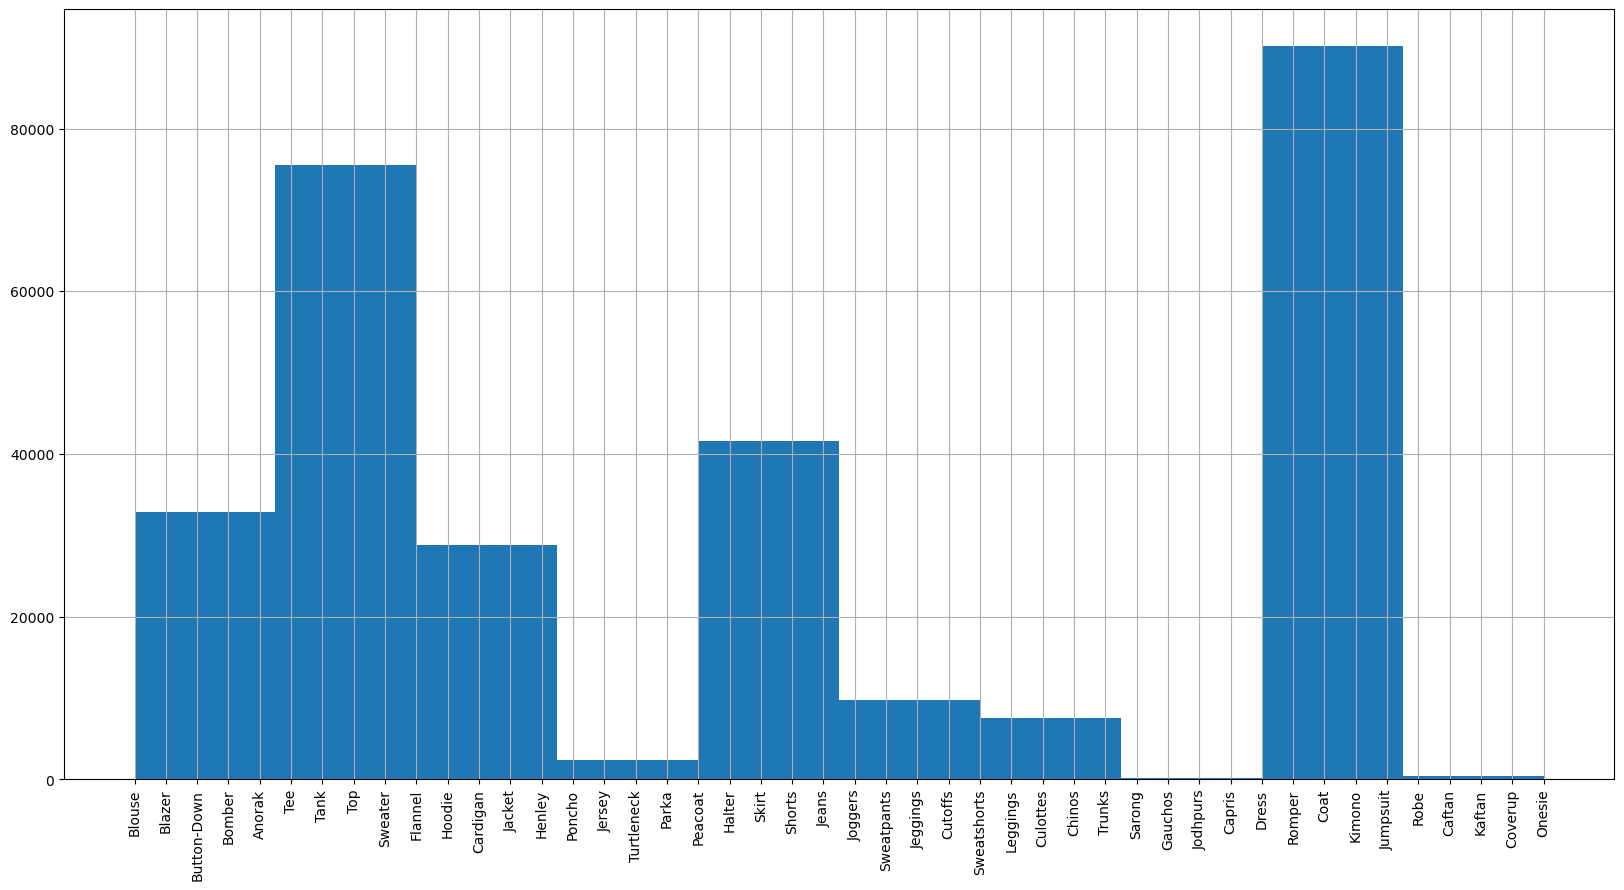

In [26]:
df_merged['category_name'].hist(xrot = 90, figsize=(20,10))